In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
DATA_PATH = "../data/processed/final_features.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (10000, 33)


,year,state,district,season,crop_type,seed_variety,area_sown_hectares,irrigation_type,rainfall_mm,temperature_min_c,...,yield_tonnes_per_hectare,sowing_year,sowing_month,sowing_day,sowing_day_of_year,temperature_range_c,rainfall_per_day,total_npk_kg_ha,np_ratio,kn_ratio
0,2022,Karnataka,Belagavi,Rabi,Maize,HQPM-1,1.52,Rainfed,573.7,17.5,...,2.82,2022,11,10,314,19.5,5.794949,221.0,1.541985,1.086634
1,2019,Karnataka,Kalaburagi,Rabi,Maize,HQPM-1,22.19,Rainfed,805.9,17.3,...,2.33,2019,11,25,329,14.2,7.393578,300.3,2.497600,0.523382
2,2019,Punjab,Amritsar,Rabi,Wheat,HD-2967,8.50,Drip Irrigated,343.2,7.5,...,2.31,2019,11,15,319,18.7,2.908475,139.8,1.144231,0.475630
3,2017,Madhya Pradesh,Jabalpur,Rabi,Wheat,HD-3086,7.48,Irrigated,339.7,14.9,...,1.72,2017,10,29,302,12.3,2.342759,227.1,1.935323,0.429306
4,2022,Rajasthan,Bikaner,Kharif,Cotton,Bunny-Bt,6.44,Rainfed,564.1,20.3,...,1.46,2022,6,4,155,13.5,3.016578,200.6,5.274900,0.325529


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Rows: 10000
Columns: 33

Column names:
['year', 'state', 'district', 'season', 'crop_type', 'seed_variety', 'area_sown_hectares', 'irrigation_type', 'rainfall_mm', 'temperature_min_c', 'temperature_max_c', 'temperature_avg_c', 'humidity_pct', 'growing_season_days', 'soil_ph', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha', 'soil_type', 'soil_moisture_pct', 'previous_yield_tonnes_ha', 'yield_trend_pct_yoy', 'ndvi', 'yield_tonnes_per_hectare', 'sowing_year', 'sowing_month', 'sowing_day', 'sowing_day_of_year', 'temperature_range_c', 'rainfall_per_day', 'total_npk_kg_ha', 'np_ratio', 'kn_ratio']


In [5]:
print("\nData types:")
display(df.dtypes)


Data types:


year                          int64
state                           str
district                        str
season                          str
crop_type                       str
seed_variety                    str
area_sown_hectares          float64
irrigation_type                 str
rainfall_mm                 float64
temperature_min_c           float64
temperature_max_c           float64
temperature_avg_c           float64
humidity_pct                float64
growing_season_days           int64
soil_ph                     float64
nitrogen_kg_ha              float64
phosphorus_kg_ha            float64
potassium_kg_ha             float64
soil_type                       str
soil_moisture_pct           float64
previous_yield_tonnes_ha    float64
yield_trend_pct_yoy         float64
ndvi                        float64
yield_tonnes_per_hectare    float64
sowing_year                   int64
sowing_month                  int64
sowing_day                    int64
sowing_day_of_year          

In [6]:
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))


Missing values:


year                        0
state                       0
district                    0
season                      0
crop_type                   0
seed_variety                0
area_sown_hectares          0
irrigation_type             0
rainfall_mm                 0
temperature_min_c           0
temperature_max_c           0
temperature_avg_c           0
humidity_pct                0
growing_season_days         0
soil_ph                     0
nitrogen_kg_ha              0
phosphorus_kg_ha            0
potassium_kg_ha             0
soil_type                   0
soil_moisture_pct           0
previous_yield_tonnes_ha    0
yield_trend_pct_yoy         0
ndvi                        0
yield_tonnes_per_hectare    0
sowing_year                 0
sowing_month                0
sowing_day                  0
sowing_day_of_year          0
temperature_range_c         0
rainfall_per_day            0
total_npk_kg_ha             0
np_ratio                    0
kn_ratio                    0
dtype: int

In [7]:
TARGET = "yield_tonnes_per_hectare"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset.")

print("Target column:", TARGET)

Target column: yield_tonnes_per_hectare


In [8]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 32)
y shape: (10000,)


In [9]:
print(y.describe())

count    10000.000000
mean         1.927589
std          0.836048
min          0.250000
25%          1.260000
50%          1.710000
75%          2.560000
max          4.890000
Name: yield_tonnes_per_hectare, dtype: float64


In [10]:
possible_id_columns = [
    col for col in X.columns
    if "id" in col.lower()
]

print("Possible ID columns:", possible_id_columns)

Possible ID columns: ['humidity_pct']


In [11]:
if "record_id" in X.columns:
    X = X.drop(columns=["record_id"])
    print("Removed record_id.")

In [12]:
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['year', 'area_sown_hectares', 'rainfall_mm', 'temperature_min_c', 'temperature_max_c', 'temperature_avg_c', 'humidity_pct', 'growing_season_days', 'soil_ph', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha', 'soil_moisture_pct', 'previous_yield_tonnes_ha', 'yield_trend_pct_yoy', 'ndvi', 'sowing_year', 'sowing_month', 'sowing_day', 'sowing_day_of_year', 'temperature_range_c', 'rainfall_per_day', 'total_npk_kg_ha', 'np_ratio', 'kn_ratio']

Categorical features:
['state', 'district', 'season', 'crop_type', 'seed_variety', 'irrigation_type', 'soil_type']


C:\Users\HP\AppData\Local\Temp\ipykernel_12592\3080918941.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [15]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [17]:
OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [18]:
linear_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [19]:
linear_regression_pipeline.fit(X_train, y_train)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [20]:
y_pred_lr = linear_regression_pipeline.predict(X_test)

In [21]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("-------------------------")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression
-------------------------
MAE  : 0.2703
RMSE : 0.3563
R²   : 0.8136


In [22]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42,
                max_depth=None
            )
        )
    ]
)

In [23]:
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [24]:
y_pred_dt = decision_tree_pipeline.predict(X_test)

In [25]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)

dt_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_dt)
)

dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("-------------------------")
print(f"MAE  : {dt_mae:.4f}")
print(f"RMSE : {dt_rmse:.4f}")
print(f"R²   : {dt_r2:.4f}")

Decision Tree
-------------------------
MAE  : 0.2896
RMSE : 0.4008
R²   : 0.7641


In [26]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                max_features="sqrt"
            )
        )
    ]
)

In [27]:
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [28]:
y_pred_rf = random_forest_pipeline.predict(X_test)

In [29]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------------------")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest
-------------------------
MAE  : 0.2297
RMSE : 0.3063
R²   : 0.8623


In [43]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.270331,0.356297,0.813579
1,Decision Tree,0.289580,0.400819,0.764078
2,Random Forest,0.229725,0.306259,0.862264


In [44]:
results.to_csv(
    "../results/nikita_results.csv",
    index=False
)

In [32]:
display(
    results.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.2703,0.3563,0.8136
1,Decision Tree,0.2896,0.4008,0.7641
2,Random Forest,0.2297,0.3063,0.8623


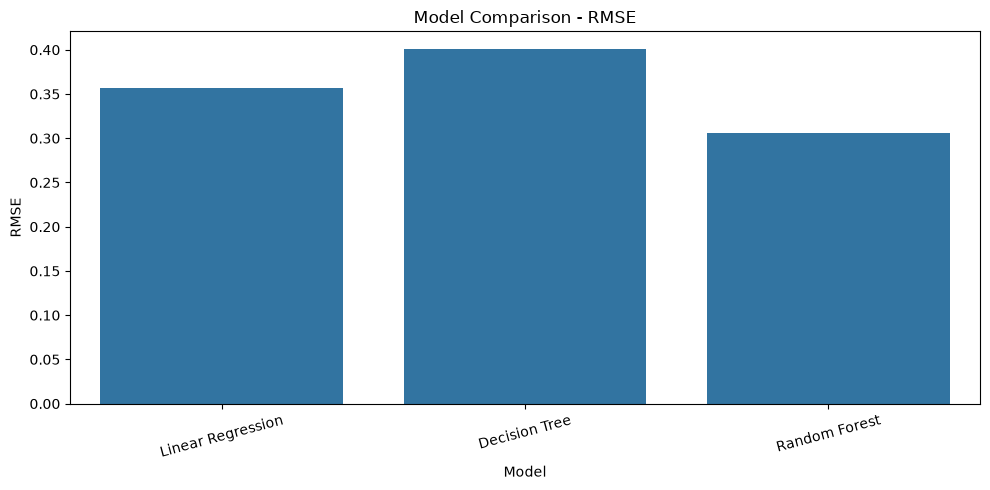

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

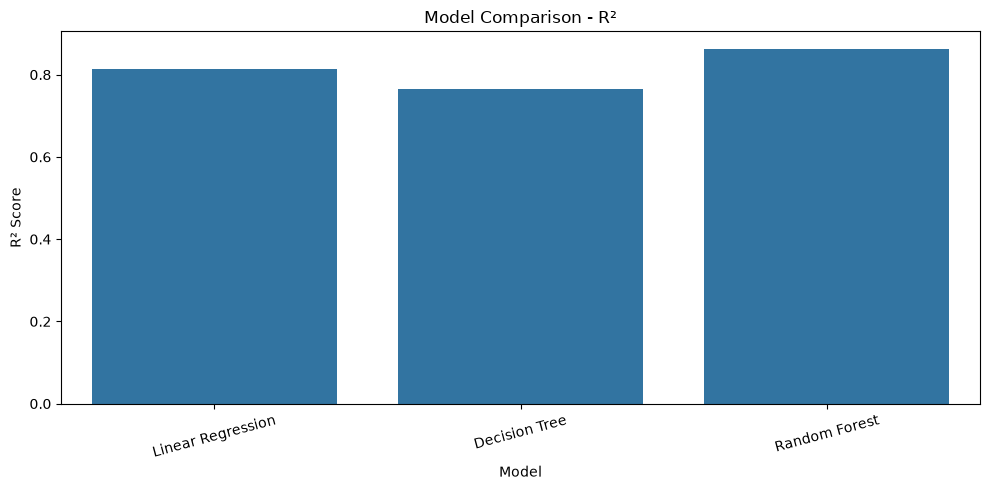

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Model Comparison - R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

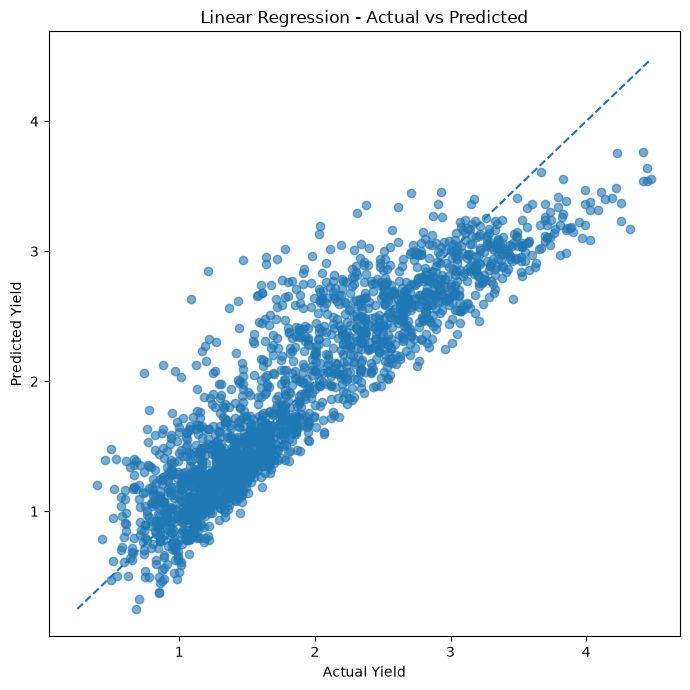

In [35]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.6
)

min_value = min(y_test.min(), y_pred_lr.min())
max_value = max(y_test.max(), y_pred_lr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Linear Regression - Actual vs Predicted")

plt.tight_layout()
plt.show()

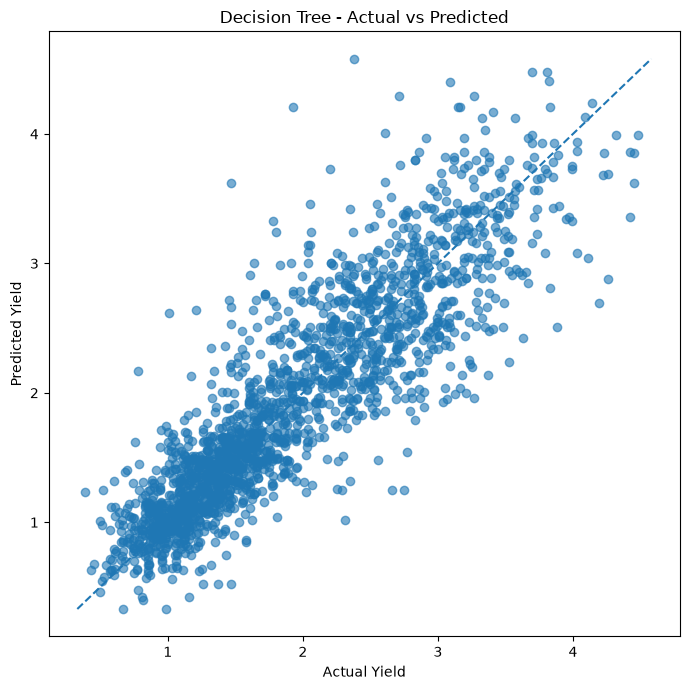

In [36]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_dt,
    alpha=0.6
)

min_value = min(y_test.min(), y_pred_dt.min())
max_value = max(y_test.max(), y_pred_dt.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Decision Tree - Actual vs Predicted")

plt.tight_layout()
plt.show()

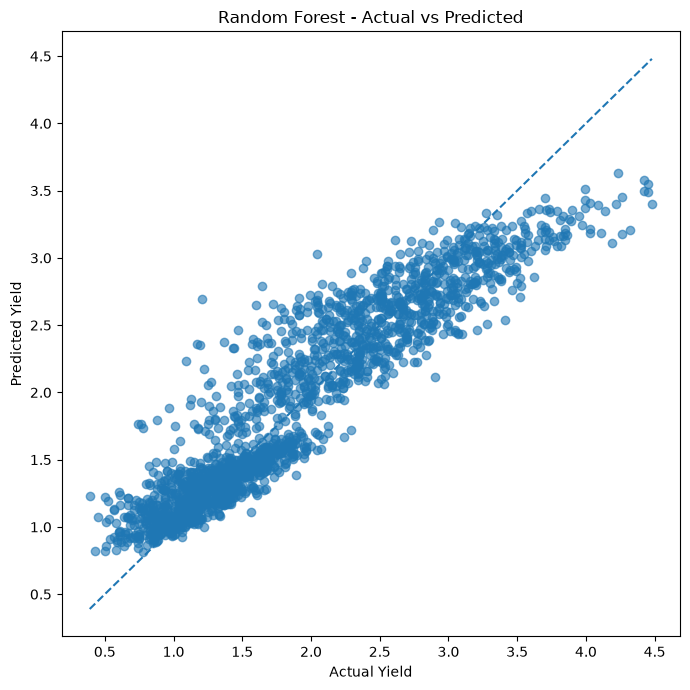

In [37]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest - Actual vs Predicted")

plt.tight_layout()
plt.show()

In [38]:
rf_preprocessor = random_forest_pipeline.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 98


In [39]:
rf_model = random_forest_pipeline.named_steps["model"]

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
13,num__previous_yield_tonnes_ha,0.182194
65,cat__crop_type_Maize,0.098173
67,cat__crop_type_Soybean,0.058970
66,cat__crop_type_Rice,0.053091
7,num__growing_season_days,0.030929
2,num__rainfall_mm,0.030048
97,cat__soil_type_Silty Loam,0.028235
64,cat__crop_type_Groundnut,0.027567
21,num__rainfall_per_day,0.023504
12,num__soil_moisture_pct,0.023111


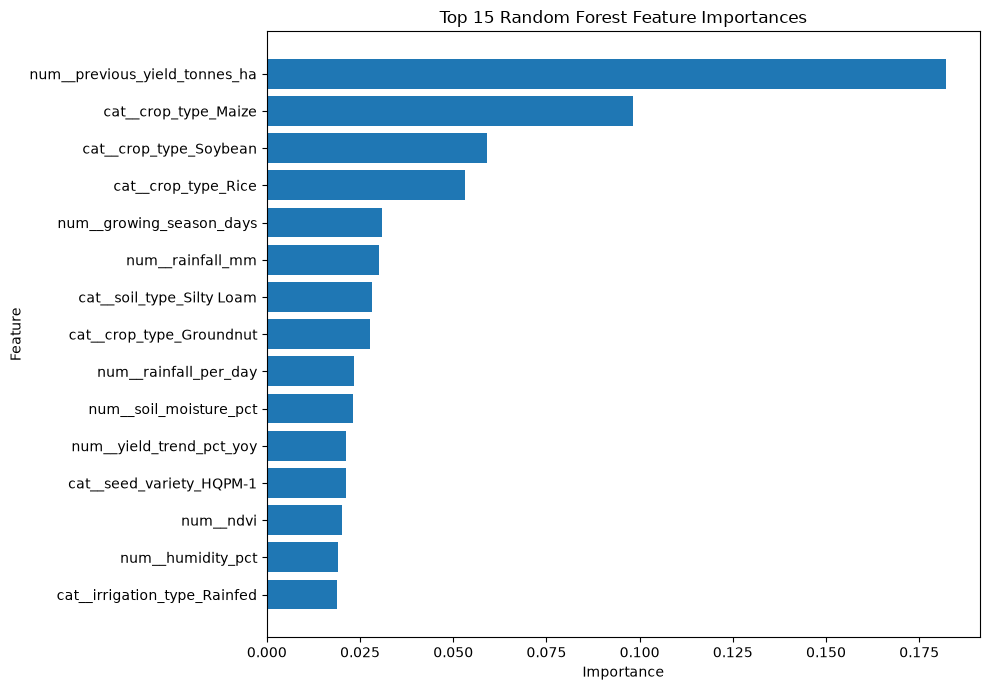

In [40]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [41]:
MODEL_DIR = Path("../models/nikita")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Model directory:", MODEL_DIR)

Model directory: ..\models\nikita


In [42]:
joblib.dump(
    linear_regression_pipeline,
    MODEL_DIR / "linear_regression.pkl"
)

joblib.dump(
    decision_tree_pipeline,
    MODEL_DIR / "decision_tree.pkl"
)

joblib.dump(
    random_forest_pipeline,
    MODEL_DIR / "random_forest.pkl"
)

print("All Nikita's models saved successfully.")

All Nikita's models saved successfully.


In [ ]:
RESULTS_DIR = Path("../results")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [ ]:
results.to_csv(
    RESULTS_DIR / "member1_results.csv",
    index=False
)

print("Results saved successfully.")

In [ ]:
print("Saved model files:")

for file in MODEL_DIR.iterdir():
    print(" -", file.name)

print("\nSaved result files:")

for file in RESULTS_DIR.iterdir():
    print(" -", file.name)

In [ ]:
loaded_rf = joblib.load(
    MODEL_DIR / "random_forest.pkl"
)

test_predictions = loaded_rf.predict(X_test)

print("Loaded model prediction successful.")
print("First 5 predictions:")
print(test_predictions[:5])

In [ ]:
print("=" * 60)
print("MEMBER 1 - TRADITIONAL ML SUMMARY")
print("=" * 60)

for _, row in results.iterrows():
    print(f"\n{row['Model']}")
    print(f"MAE  : {row['MAE']:.4f}")
    print(f"RMSE : {row['RMSE']:.4f}")
    print(f"R²   : {row['R2']:.4f}")

print("\nModels saved in:")
print(MODEL_DIR)

print("\nResults saved in:")
print(RESULTS_DIR / "member1_results.csv")